## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Load Dataset

In [2]:
# Load real and fake news datasets
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

print('✅ Dataset loaded!')
print(f'Real news articles : {len(true_df)}')
print(f'Fake news articles : {len(fake_df)}')

✅ Dataset loaded!
Real news articles : 21417
Fake news articles : 23481


In [3]:
# Add labels: 1 = Real, 0 = Fake
true_df['label'] = 1
fake_df['label'] = 0

# Combine both datasets
df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Shape of combined dataset:', df.shape)
df.head()

Shape of combined dataset: (44898, 5)


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


## Step 3: Explore Data (EDA)

In [4]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


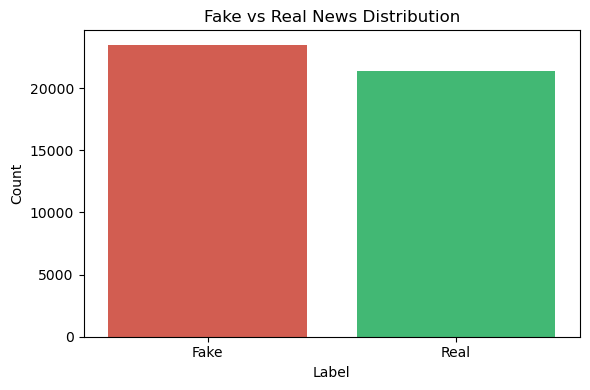

In [5]:
# Visualize label distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Fake vs Real News Distribution')
plt.xticks([0, 1], ['Fake', 'Real'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 4: Preprocess Text

In [6]:
def clean_text(text):
    """Clean and preprocess news text"""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Combine title and text for better accuracy
df['content'] = df['title'] + ' ' + df['text']
df['content'] = df['content'].apply(clean_text)

print('✅ Text preprocessing done!')
print('Sample cleaned text:')
print(df['content'][0][:300])

✅ Text preprocessing done!
Sample cleaned text:
breaking gop chairman grassley has had enough demands trump jr testimony donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems surrounding all of this to them it s fake news or a


## Step 5: Feature Extraction using TF-IDF

In [7]:
# Split into features and labels
X = df['content']
y = df['label']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 35918
Testing samples  : 8980


In [8]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('✅ TF-IDF vectorization done!')
print('Feature matrix shape:', X_train_tfidf.shape)

✅ TF-IDF vectorization done!
Feature matrix shape: (35918, 10000)


## Step 6: Train Model

In [9]:
# ----- Model 1: Passive Aggressive Classifier -----
pac = PassiveAggressiveClassifier(max_iter=50, random_state=42)
pac.fit(X_train_tfidf, y_train)

y_pred_pac = pac.predict(X_test_tfidf)
acc_pac = accuracy_score(y_test, y_pred_pac)

print(f'✅ Passive Aggressive Classifier Accuracy: {acc_pac * 100:.2f}%')

✅ Passive Aggressive Classifier Accuracy: 99.33%


In [10]:
# ----- Model 2: Logistic Regression -----
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f'✅ Logistic Regression Accuracy: {acc_lr * 100:.2f}%')

✅ Logistic Regression Accuracy: 98.69%


## Step 7: Evaluate Model

In [11]:
# Use best model (Passive Aggressive)
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_pac, target_names=['Fake', 'Real']))

=== Classification Report ===
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4669
        Real       0.99      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



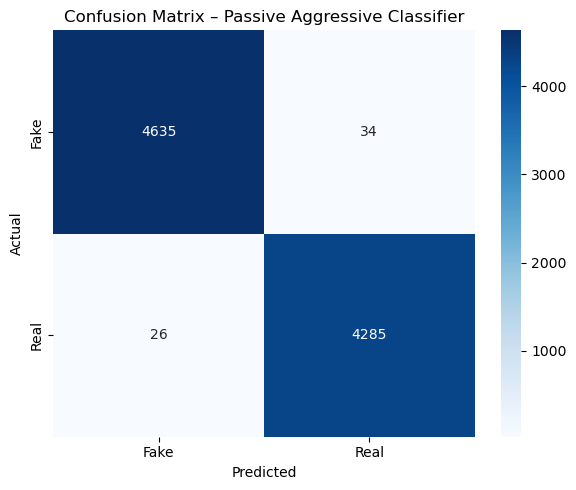

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pac)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix – Passive Aggressive Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

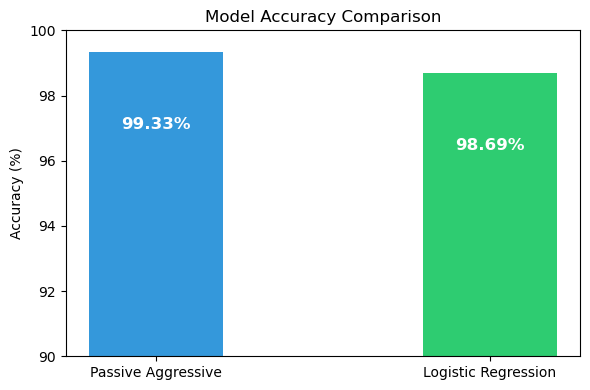

In [13]:
# Accuracy comparison bar chart
models = ['Passive Aggressive', 'Logistic Regression']
accuracies = [acc_pac * 100, acc_lr * 100]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=['#3498db', '#2ecc71'], width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
             f'{acc:.2f}%', ha='center', va='top', fontsize=12, color='white', fontweight='bold')
plt.ylim([90, 100])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

## Step 8: Test on Custom Input 
Try entering any news headline to see if it's REAL or FAKE!

In [14]:
def predict_news(news_text):
    """Predict whether a news article is REAL or FAKE"""
    cleaned = clean_text(news_text)
    vectorized = tfidf.transform([cleaned])
    prediction = pac.predict(vectorized)[0]
    label = '✅ REAL News' if prediction == 1 else '❌ FAKE News'
    print(f'Prediction: {label}')


# ----------- Test Examples -----------
predict_news("NASA confirms water found on the moon surface after new research")
predict_news("Scientists prove that drinking bleach cures cancer instantly")

Prediction: ❌ FAKE News
Prediction: ❌ FAKE News




| Step | Description |
|------|-------------|
| Dataset | True.csv + Fake.csv from Kaggle |
| Preprocessing | Lowercase, remove URLs, punctuation |
| Vectorization | TF-IDF (10,000 features) |
| Models Used | Passive Aggressive, Logistic Regression |
| Expected Accuracy | ~92–98% |

